In [1]:
from utils import *
from concurrent.futures import ProcessPoolExecutor
import concurrent


In [2]:
import numpy as np
import qutip

def truncate(qobj: qutip.Qobj, dimension: int) -> qutip.Qobj:
    if qobj.shape[1] == 1:  # is ket
        return qutip.Qobj(qobj.full()[:dimension, :])
    else:  # is operator or density matrix
        return qutip.Qobj(qobj.full()[:dimension, :dimension])

def pad_back(qobj: qutip.Qobj, full_dimension: int) -> qutip.Qobj:
    if qobj.shape[1] == 1:  # is ket
        truncated_dim = qobj.shape[0]
        padded_vector = np.zeros((full_dimension, 1), dtype=complex)
        padded_vector[:truncated_dim, :] = qobj.full()
        return qutip.Qobj(padded_vector)
    else:  # is operator or density matrix
        truncated_dim = qobj.shape[0]
        padded_matrix = np.zeros((full_dimension, full_dimension), dtype=complex)
        padded_matrix[:truncated_dim, :truncated_dim] = qobj.full()
        return qutip.Qobj(padded_matrix)
    



def truncate_by_qubit_level(qobj: qutip.Qobj, max_qubit_level: int, product_to_dressed: dict) -> qutip.Qobj:
    indices_to_keep = [dressed_level for (qubit_level, _), dressed_level in product_to_dressed.items() if qubit_level < max_qubit_level]
    indices_to_keep.sort()
    if qobj.shape[1] == 1:  # is ket
        truncated_vector = qobj.full()[indices_to_keep, :]
        return qutip.Qobj(truncated_vector)
    else:  # is operator or density matrix
        truncated_matrix = qobj.full()[np.ix_(indices_to_keep, indices_to_keep)]
        return qutip.Qobj(truncated_matrix)

def pad_back_from_qubit_level(qobj: qutip.Qobj, max_qubit_level, product_to_dressed: dict) -> qutip.Qobj:
    indices_to_keep = [dressed_level for (qubit_level, _), dressed_level in product_to_dressed.items() if qubit_level < max_qubit_level]
    indices_to_keep.sort()
    full_dimension = max(product_to_dressed.values())+1
    if qobj.shape[1] == 1:  # is ket
        padded_vector = np.zeros((full_dimension, 1), dtype=complex)
        padded_vector[indices_to_keep, :] = qobj.full()
        return qutip.Qobj(padded_vector)
    else:  # is operator or density matrix
        padded_matrix = np.zeros((full_dimension, full_dimension), dtype=complex)
        padded_matrix[np.ix_(indices_to_keep, indices_to_keep)] = qobj.full()
        return qutip.Qobj(padded_matrix)
    
def test_truncate_by_ql():
    product_to_dressed = {(0, 0): 0, 
                        (1, 0): 1, 
                        (0, 1): 2, 
                        (1, 1): 3, 
                        (2, 0): 4, 
                        (0, 2): 5, 
                        (1, 2): 6, 
                        (2, 1): 7, 
                        (2, 2): 8}


    # Example qubit operator (replace this with your actual qubit operator)
    qubit_operator = qutip.tensor(qutip.Qobj(np.array([
        [0,1,2],
        [3,4,5],
        [6,7,8]
    ])), qutip.identity(3))  

    # Truncate
    truncated_qubit_operator = truncate_by_qubit_level(qubit_operator, 2, product_to_dressed)

    # Pad back
    padded_back_qubit_operator = pad_back_from_qubit_level(truncated_qubit_operator, 2, product_to_dressed)
    assert  np.allclose(truncated_qubit_operator, np.array([[0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j, 2.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j],
       [3.+0.j, 0.+0.j, 0.+0.j, 4.+0.j, 0.+0.j, 5.+0.j],
       [0.+0.j, 0.+0.j, 3.+0.j, 0.+0.j, 4.+0.j, 0.+0.j],
       [6.+0.j, 0.+0.j, 0.+0.j, 7.+0.j, 0.+0.j, 8.+0.j]]))
    assert np.allclose(padded_back_qubit_operator, np.array(np.array([
        [0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j, 2.+0.j, 0.+0.j,0.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j,0.+0.j],
       [3.+0.j, 0.+0.j, 0.+0.j, 4.+0.j, 0.+0.j, 0.+0.j, 5.+0.j, 0.+0.j,0.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 3.+0.j, 0.+0.j, 0.+0.j, 4.+0.j, 0.+0.j, 0.+0.j,0.+0.j],
       [6.+0.j, 0.+0.j, 0.+0.j, 7.+0.j, 0.+0.j, 0.+0.j, 8.+0.j, 0.+0.j,0.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,0.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j]]))), str(padded_back_qubit_operator)
    

test_truncate_by_ql()



def truncate_by_qubit_level_and_states(qobj: qutip.Qobj, max_qubit_level: int, truncated_dim: int, product_to_dressed: dict) -> qutip.Qobj:
    indices_to_keep = [dressed_level for (qubit_level, _), dressed_level in product_to_dressed.items() if qubit_level < max_qubit_level]
    indices_to_keep.sort()
    indices_to_keep = indices_to_keep[:truncated_dim]  # Apply the cap on the total number of states

    if qobj.shape[1] == 1:  # is ket
        truncated_vector = qobj.full()[indices_to_keep, :]
        return qutip.Qobj(truncated_vector)
    else:  # is operator or density matrix
        truncated_matrix = qobj.full()[np.ix_(indices_to_keep, indices_to_keep)]
        return qutip.Qobj(truncated_matrix)

def pad_back_from_qubit_level_and_states(qobj: qutip.Qobj, max_qubit_level, truncated_dim, product_to_dressed: dict) -> qutip.Qobj:
    indices_to_keep = [dressed_level for (qubit_level, _), dressed_level in product_to_dressed.items() if qubit_level < max_qubit_level]
    indices_to_keep.sort()
    indices_to_keep = indices_to_keep[:truncated_dim]  # Apply the cap on the total number of states

    full_dimension = max(product_to_dressed.values()) + 1
    if qobj.shape[1] == 1:  # is ket
        padded_vector = np.zeros((full_dimension, 1), dtype=complex)
        padded_vector[indices_to_keep, :] = qobj.full()
        return qutip.Qobj(padded_vector)
    else:  # is operator or density matrix
        padded_matrix = np.zeros((full_dimension, full_dimension), dtype=complex)
        padded_matrix[np.ix_(indices_to_keep, indices_to_keep)] = qobj.full()
        return qutip.Qobj(padded_matrix)
    

def test_truncate_and_pad_with_states():
    # Define the mapping between product basis states and dressed states
    product_to_dressed = {(0, 0): 0, 
                            (1, 0): 1, 
                            (0, 1): 2, 
                            (1, 1): 3, 
                            (2, 0): 4, 
                            (0, 2): 5, 
                            (1, 2): 6, 
                            (2, 1): 7, 
                            (2, 2): 8}

    # Create an example qubit operator
    qubit_operator = qutip.tensor(qutip.Qobj(np.array([
        [0, 1, 2],
        [3, 4, 5],
        [6, 7, 8]
    ])), qutip.identity(3))

    # Truncate
    truncated_qubit_operator = truncate_by_qubit_level_and_states(qubit_operator, max_qubit_level=2, truncated_dim=5, product_to_dressed=product_to_dressed)

    # Pad back
    padded_back_qubit_operator = pad_back_from_qubit_level_and_states(truncated_qubit_operator, max_qubit_level=2, truncated_dim=5, product_to_dressed=product_to_dressed)

    # Check the validity of the truncation and padding operations
    truncated_expected = np.array([
        [0, 0, 0, 1, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 1],
        [3, 0, 0, 4, 0],
        [0, 0, 3, 0, 4]
    ], dtype=complex)

    assert np.allclose(truncated_qubit_operator.full(), truncated_expected), f"Truncated does not match: \n{truncated_qubit_operator.full()}"

    padded_expected = np.array([
        [0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
        [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,0.+0.j],
        [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j,0.+0.j],
        [3.+0.j, 0.+0.j, 0.+0.j, 4.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,0.+0.j],
        [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,0.+0.j],
        [0.+0.j, 0.+0.j, 3.+0.j, 0.+0.j, 0.+0.j, 4.+0.j, 0.+0.j, 0.+0.j,0.+0.j],
        [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,0.+0.j],
        [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
        [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j]], dtype=complex)

    assert np.allclose(padded_back_qubit_operator.full(), padded_expected), f"Padded does not match:\n{padded_back_qubit_operator.full() == padded_expected}"

test_truncate_and_pad_with_states()



def truncate_custom(qobj: qutip.Qobj, products_to_keep: list, product_to_dressed: dict) -> qutip.Qobj:
    indices_to_keep = [dressed_level for (qubit_level, oscillator_level), dressed_level in product_to_dressed.items() if [qubit_level, oscillator_level] in products_to_keep]
    indices_to_keep.sort()

    if qobj.shape[1] == 1:  # is ket
        truncated_vector = qobj.full()[indices_to_keep, :]
        return qutip.Qobj(truncated_vector)
    else:  # is operator or density matrix
        truncated_matrix = qobj.full()[np.ix_(indices_to_keep, indices_to_keep)]
        return qutip.Qobj(truncated_matrix)

def pad_back_custom(qobj: qutip.Qobj, products_to_keep: list, product_to_dressed: dict) -> qutip.Qobj:
    indices_to_keep = [dressed_level for (qubit_level, oscillator_level), dressed_level in product_to_dressed.items() if [qubit_level, oscillator_level] in products_to_keep]
    indices_to_keep.sort()

    full_dimension = max(product_to_dressed.values()) + 1

    if qobj.shape[1] == 1:  # is ket
        padded_vector = np.zeros((full_dimension, 1), dtype=complex)
        padded_vector[indices_to_keep, :] = qobj.full()
        return qutip.Qobj(padded_vector)
    else:  # is operator or density matrix
        padded_matrix = np.zeros((full_dimension, full_dimension), dtype=complex)
        padded_matrix[np.ix_(indices_to_keep, indices_to_keep)] = qobj.full()
        return qutip.Qobj(padded_matrix)

def test_truncate_and_pad_custom():
    # Define the mapping between product basis states and dressed states
    product_to_dressed = {(0, 0): 0, 
                            (1, 0): 1, 
                            (0, 1): 2, 
                            (1, 1): 3, 
                            (2, 0): 4, 
                            (0, 2): 5, 
                            (1, 2): 6, 
                            (2, 1): 7, 
                            (2, 2): 8}

    # Specify which products to keep
    products_to_keep = [[0, 0], [0, 1], [0, 2], [1, 0], [1, 1], [1, 2]]

    # Create an example qubit operator
    qubit_operator = qutip.tensor(qutip.Qobj(np.array([
        [0, 1, 2],
        [3, 4, 5],
        [6, 7, 8]
    ])), qutip.identity(3))

    # Truncate using custom function
    truncated_qubit_operator = truncate_custom(qubit_operator, products_to_keep, product_to_dressed)

    # Pad back using custom function
    padded_back_qubit_operator = pad_back_custom(truncated_qubit_operator, products_to_keep, product_to_dressed)

    # Expected truncated matrix based on products_to_keep
    truncated_expected = np.array([
        [0, 0, 0, 1, 0 ,2],
        [0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 1, 0],
        [3, 0, 0, 4, 0, 5],
        [0, 0, 3, 0, 4, 0],
        [6, 0, 0, 7, 0, 8]
    ], dtype=complex)

    assert np.allclose(truncated_qubit_operator.full(), truncated_expected), f"Truncated does not match: \n{truncated_qubit_operator.full()}"

    padded_expected = np.array([
        [0, 0, 0, 1, 0, 0 ,2, 0,0],
        [0, 0, 0, 0, 0, 0, 0, 0,0],
        [0, 0, 0, 0, 0, 1, 0, 0,0],
        [3, 0, 0, 4, 0, 0, 5, 0,0],
        [0, 0, 0, 0, 0, 0, 0, 0,0],
        [0, 0, 3, 0, 0, 4, 0, 0,0],
        [6, 0, 0, 7, 0, 0, 8, 0,0],
        [0, 0, 0, 0, 0, 0, 0, 0,0],
        [0, 0, 0, 0, 0, 0, 0, 0,0],
    ], dtype=complex)

    assert np.allclose(padded_back_qubit_operator.full(), padded_expected), f"Padded does not match:\n{padded_expected == padded_back_qubit_operator.full()}"

test_truncate_and_pad_custom()

In [3]:
from bidict import bidict
def plot_specturum(qubit, resonator, hilbertspace, num_levels = 20,
                    flagged_transitions = [[[0,0],[0,1]],[[1,0],[1,1]],[[2,0],[2,1]]]):
    product_to_dressed = generate_single_mapping(hilbertspace.hamiltonian())
    energy_text_size = 8
    # clear_output(wait=True)
    
    fig, old_ax = qubit.plot_wavefunction(which = [0,1,2,3,4,5,6,7,8,9,10,11])
    left, bottom, width, height = 1, 0, 1, 1  
    ax = fig.add_axes([left, bottom, width, height])
    fig.set_size_inches(8, 8)

    product_to_dressed = bidict(product_to_dressed)
    qls = [product[0] for product in [product_to_dressed.inv[l] for l in range(num_levels)]]
    rls = [product[1] for product in [product_to_dressed.inv[l] for l in range(num_levels)]]
    max_qubit_level = max(qls) +1 
    max_resonator_level = max(rls) +1
    qubit_ori_energies = qubit.eigenvals(max_qubit_level)
    resonator_ori_energies = resonator.eigenvals(max_resonator_level)

    
    max_rl_for_ql = [0] *3
    for l in range(num_levels):
        (ql,rl) = product_to_dressed.inv[l]
        original = (qubit_ori_energies[ql] + resonator_ori_energies[rl])#* 2 * np.pi
        x1,x2 = ql-0.25,ql+0.25
        ax.plot([x1, x2], [original, original], linewidth=1, color='red')
        ax.text(ql, original, f"{original:.3f}", fontsize=energy_text_size, ha='center', va='bottom')

        dressed_state_index = product_to_dressed[(ql,rl)]
        dressed = hilbertspace.energy_by_dressed_index(dressed_state_index)#* 2 * np.pi
        ax.plot([x1, x2], [dressed, dressed], linewidth=1, color='green')
        ax.text(ql, dressed, f"{dressed:.3f}", fontsize=energy_text_size, ha='center', va='top')

        if ql in [0,1,2]:
            if rl > max_rl_for_ql[ql]:
                max_rl_for_ql[ql]=rl

    flagged_transitions = []
    for ql in [0,1,2]:
        for i in range(max_rl_for_ql[ql] ):
            flagged_transitions.append([[ql,i],[ql,i+1]])
    for transition in flagged_transitions:
        state1, state2 = transition[0],transition[1]
        dressed_index1 = product_to_dressed[(state1[0],state1[1])]
        dressed_index2 = product_to_dressed[(state2[0],state2[1])]
        if dressed_index1!= None and dressed_index2!= None:
            energy1 = hilbertspace.energy_by_dressed_index(dressed_index1)#* 2 * np.pi
            energy2 = hilbertspace.energy_by_dressed_index(dressed_index2)#* 2 * np.pi
            ax.plot([state1[0], max_qubit_level], [energy2, energy2], linewidth=1, color='green')
            ax.plot([state1[0], state2[0]], [energy1, energy2], linewidth=1, color='green')
            ax.text((state1[0]+ state2[0])/2, (energy1+ energy2)/2, f"{energy2-energy1:.3f}", fontsize=energy_text_size, ha='center', va='top')
        else:
            print("dressed_state_index contain None")
    plt.show()

qubit bare energy:
0-3: 7.1632781179490745
1-4: 6.276748552887263
2-5: 7.882663225287895
1-6: 10.712827600549677
2-7: 12.282663802122674
1-2 0.09839380348252291

differential_stark_on_qubit_12 transition
osc 0: 0.09837911389169696
osc 1:0.09826834613845037, diff to previous -0.00011076775324658783
osc 2:0.09815763409681466, diff to previous -0.00011071204163570769
osc 3:0.0980469776774413, diff to previous -0.00011065641937335613
osc 4:0.09793637678930622, diff to previous -0.00011060088813508173
osc 5:0.09782583133991807, diff to previous -0.00011054544938815525
osc 6:0.09771534123662207, diff to previous -0.00011049010329600151
osc 7:0.09760490638510078, diff to previous -0.00011043485152129051

for qubit in 	1 		 2 		 0:
osc 0-1: 	12.11653	12.11642	12.12961
osc 1-2: 	12.11653	12.11642	12.12187  non-linearity to previous -0.007735094805454423
osc 2-3: 	12.11653	12.11642	12.12056  non-linearity to previous -0.0013158271064561688
osc 3-4: 	12.11653	12.11642	12.11988  non-linearity to p

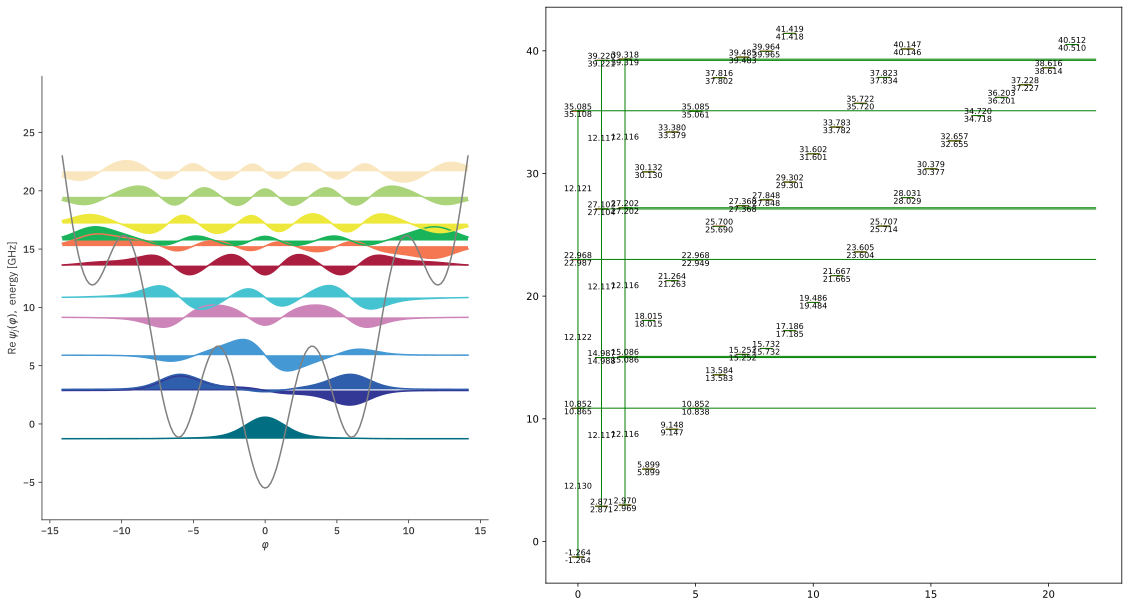

In [4]:
g_strength = 0.1
EJ = 5.5
EC = 2.0
EL = 0.23

qubit_level = 30
osc_level = 60
qbt = scqubits.Fluxonium(EJ=EJ,EC=EC,EL=EL,flux=0,cutoff=110,truncated_dim=qubit_level)


evals = qbt.eigenvals(10)
E_osc = evals[5]-evals[0]

osc = scqubits.Oscillator(E_osc=E_osc,truncated_dim=osc_level)
hilbertspace = scqubits.HilbertSpace([qbt, osc])
hilbertspace.add_interaction(g_strength=g_strength,op1=qbt.n_operator,op2=osc.creation_operator,add_hc=True)
hilbertspace.generate_lookup()
product_to_dressed = generate_single_mapping(hilbertspace.hamiltonian())
energies=  hilbertspace.eigenvals(qubit_level*osc_level)
def dressed_ener(ql,ol):
    return energies[product_to_dressed[(ql,ol)]]
def print_stats():
    print(f"qubit bare energy:")
    print(f"0-3: {evals[3]-evals[0]}")
    print(f"1-4: {evals[4]-evals[1]}")
    print(f"2-5: {evals[5]-evals[2]}")
    print(f"1-6: {evals[6]-evals[1]}")
    print(f"2-7: {evals[7]-evals[2]}")
    print(f"1-2 {qbt.eigenvals()[2]-qbt.eigenvals()[1]}")


    print(f"\ndifferential_stark_on_qubit_12 transition")
    print(f"osc {0}: {(dressed_ener(2,0)-dressed_ener(1,0))}")
    for i in range(1,8):
        print(f"osc {i}:{(dressed_ener(2,i)-dressed_ener(1,i))}, diff to previous {(dressed_ener(2,i)-dressed_ener(1,i))  -(dressed_ener(2,i-1)-dressed_ener(1,i-1))}")

    print(f"\nfor qubit in \t1 \t\t 2 \t\t 0:")
    print(f"osc 0-1: \t{dressed_ener(1,1)-dressed_ener(1,0):.5f}\t{dressed_ener(2,1)-dressed_ener(2,0):.5f}\t{dressed_ener(0,1)-dressed_ener(0,0):.5f}")
    for i in range(1,15):
        print(f"osc {i}-{i+1}: \t{dressed_ener(1,i+1)-dressed_ener(1,i):.5f}\t{dressed_ener(2,i+1)-dressed_ener(2,i):.5f}\t{dressed_ener(0,i+1)-dressed_ener(0,i):.5f}  non-linearity to previous {(dressed_ener(0,i+1)-dressed_ener(0,i))  -(dressed_ener(0,i)-dressed_ener(0,i-1))}")

    print(f"")
    print(f"10-11: {(dressed_ener(1,1)-dressed_ener(1,0)):.4f}, diff to 00-01: {abs((dressed_ener(0,1)-dressed_ener(0,0))    -(dressed_ener(1,1)-dressed_ener(1,0)))}")
    print(f"20-21: {(dressed_ener(2,1)-dressed_ener(2,0)):.4f}, diff to 00-01: {abs((dressed_ener(0,1)-dressed_ener(0,0))    -(dressed_ener(2,1)-dressed_ener(2,0)))}")
print_stats()

plot_specturum(qbt, osc, hilbertspace,num_levels = 50)

In [21]:
products_to_keep = []
#want to keep 50 levels for qubit in 0th state
for ol in range(20):
    products_to_keep.append([0,ol])
# keep 5 levels for other qubit levels
for ql in range(1,8):
    for ol in range(10):
        products_to_keep.append([ql,ol])

def truncate_function(qobj):
    return truncate_custom(qobj, products_to_keep, product_to_dressed)


a = hilbertspace.op_in_dressed_eigenbasis(op=osc.annihilation_operator)
a = qutip.Qobj(a[:, :])
a_trunc = truncate_function(a)

(evals,) = hilbertspace["evals"]
diag_dressed_hamiltonian = (
        2 * np.pi * qutip.Qobj(np.diag(evals),
        dims=[hilbertspace.subsystem_dims] * 2)
)
diag_dressed_hamiltonian = qutip.Qobj(diag_dressed_hamiltonian[:, :])
diag_dressed_hamiltonian = truncate_function(diag_dressed_hamiltonian)


w_d = transition_frequency(hilbertspace,product_to_dressed[(0,0)],product_to_dressed[(0,1)] )
w_d_1 = transition_frequency(hilbertspace,product_to_dressed[(0,7)],product_to_dressed[(0,8)] )

amp1 = 0.007
amp2 = 0.004

stop_t = abs(a[product_to_dressed[(0,0)],product_to_dressed[(0,1)]])/amp1
stop_t2 = abs(a[product_to_dressed[(0,2)],product_to_dressed[(0,3)]])/amp2


tot_time =int(stop_t)
tlist = np.linspace(0, tot_time, tot_time*2)


kappa = 0.01
decay_term = np.sqrt(kappa) * a_trunc


In [22]:

# stop_t, stop_t2

In [23]:
def write_function():
    with open('temp_functions.py', 'w') as f:
        f.write(f"""
from utils import *
            
w_d = {w_d}
w_d_1 = {w_d_1}

amp1 = {amp1}
amp2 = {amp2}

stop_t = {stop_t}
stop_t2 = {stop_t2}

product_to_dressed = {product_to_dressed}
products_to_keep = {products_to_keep}
def square_cos(t, *args):
    cos = np.cos(w_d * 2 * np.pi * t)
    return 2 * np.pi * amp1 * cos

def square_cos_part1(t, *args):
    if t>stop_t:
        return 0
    else:
        cos = np.cos(w_d * 2 * np.pi * t)
        return 2 * np.pi * amp1 * cos

def square_cos_part2(t, *args):
    if t<=stop_t:
        return 0
    else:
        cos = np.cos(w_d_1 * 2 * np.pi * t)
        return 2 * np.pi * amp2 * cos

    

def pad_back_custom(qobj: qutip.Qobj, products_to_keep: list, product_to_dressed: dict) -> qutip.Qobj:
    indices_to_keep = [dressed_level for (qubit_level, oscillator_level), dressed_level in product_to_dressed.items() if [qubit_level, oscillator_level] in products_to_keep]
    indices_to_keep.sort()

    full_dimension = max(product_to_dressed.values()) + 1

    if qobj.shape[1] == 1:  # is ket
        padded_vector = np.zeros((full_dimension, 1), dtype=complex)
        padded_vector[indices_to_keep, :] = qobj.full()
        return qutip.Qobj(padded_vector)
    else:  # is operator or density matrix
        padded_matrix = np.zeros((full_dimension, full_dimension), dtype=complex)
        padded_matrix[np.ix_(indices_to_keep, indices_to_keep)] = qobj.full()
        return qutip.Qobj(padded_matrix)

def mesolve_and_pad(rho0,
            H_with_drive,
             tlist, 
            full_dim,
            c_ops = None
            ):

            
    temp = qutip.mesolve(
        H=H_with_drive,
        rho0=rho0,
        tlist=tlist,
        c_ops=c_ops,
        options=qutip.Options(store_states=True, nsteps=8000, num_cpus=1),
        progress_bar = True
    )

    # padded_states = [pad_back(state, full_dim) for state in temp.states]
    
    padded_states = [pad_back_custom(state, products_to_keep, product_to_dressed) for state in temp.states]
    return CustomOdeResult(times=temp.times, states=padded_states)
""")
write_function()


In [24]:

from temp_functions import mesolve_and_pad, square_cos, square_cos_part1, square_cos_part2
H_with_drive = [
    diag_dressed_hamiltonian,
    [a_trunc+a_trunc.dag(), square_cos],
    # [a_trunc+a_trunc.dag(), square_cos_part2]
]

results = [None] * 4
with ProcessPoolExecutor(max_workers=4) as executor:
    futures = {executor.submit(mesolve_and_pad, 
                               rho0=truncate_function(qutip.basis(hilbertspace.dimension, product_to_dressed[(i, 0)])), 
                               H_with_drive=H_with_drive,
                               tlist=tlist, 
                               full_dim=hilbertspace.dimension,
                            #    c_ops = [decay_term],  
                               ): i for i in range(4)}
    
    for future in concurrent.futures.as_completed(futures):
        original_index = futures[future]
        results[original_index] = future.result()


os.remove('temp_functions.py')


10.3%. Run time:   0.97s. Est. time left: 00:00:00:08
10.3%. Run time:   0.99s. Est. time left: 00:00:00:08
10.3%. Run time:   0.99s. Est. time left: 00:00:00:08
10.3%. Run time:   1.01s. Est. time left: 00:00:00:08
20.1%. Run time:   1.90s. Est. time left: 00:00:00:07
20.1%. Run time:   1.91s. Est. time left: 00:00:00:07
20.1%. Run time:   1.91s. Est. time left: 00:00:00:07
20.1%. Run time:   1.94s. Est. time left: 00:00:00:07
30.4%. Run time:   2.83s. Est. time left: 00:00:00:06
30.4%. Run time:   2.85s. Est. time left: 00:00:00:06
30.4%. Run time:   2.85s. Est. time left: 00:00:00:06
30.4%. Run time:   2.90s. Est. time left: 00:00:00:06
40.2%. Run time:   3.71s. Est. time left: 00:00:00:05
40.2%. Run time:   3.77s. Est. time left: 00:00:00:05
40.2%. Run time:   3.78s. Est. time left: 00:00:00:05
40.2%. Run time:   3.84s. Est. time left: 00:00:00:05
50.0%. Run time:   4.63s. Est. time left: 00:00:00:04
50.0%. Run time:   4.69s. Est. time left: 00:00:00:04
50.0%. Run time:   4.70s. Es

 /Users/jiakaiwang/opt/miniconda3/envs/tensorflow/lib/python3.10/site-packages/jax/_src/array.py: 343

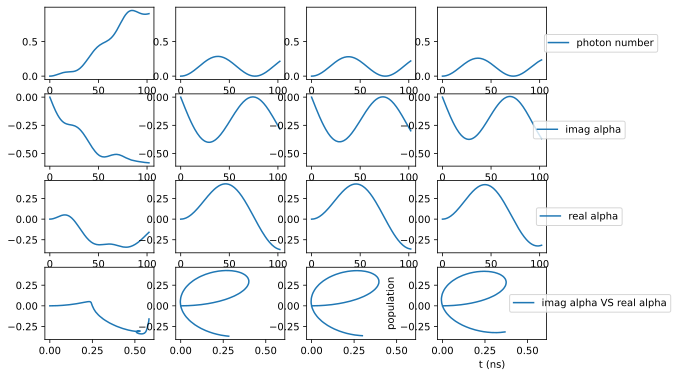

In [25]:
plot_population(results,qubit_level,osc_level,product_to_dressed,a,w_d,tlist,fourier=True,fix_ylim=True,plot_only_pn_alpha= True)

In [26]:
interactive_heatmap(results[0], product_to_dressed, qubit_levels=qubit_level, oscillator_levels=osc_level)

interactive(children=(IntSlider(value=0, continuous_update=False, description='Time Index:', max=203), Output(…

In [36]:
def compute_contrast(results, res_idx1,res_idx2,# Which two results to compute contrast between
                     coeff, # in GHz
                     a,w_d,tlist,
                     fourier):
    
    # Step-1 compute expectation of alpha and put it in result.expect
    a_op = jnp.array(a.full())

    vectorized_compute_expectation = get_vectorized_compute_expectation_function()

    alphas = []
    for i in [res_idx1,res_idx2]:
        if hasattr(results[i], 'y'):
            states = jnp.array(results[i].y)  # assuming y contains JAX arrays or density matrices (obtained from qiskit solver)
        elif hasattr(results[i], 'states'):
            states = jnp.stack([jnp.array(q.full()) for q in results[i].states])  # assuming states contains QObj or density matrices (obtained from qutip-like solver)
        
        alpha_expect = vectorized_compute_expectation(states, a_op)
        alphas.append(alpha_expect)

    if fourier == True:
        first_dominant_freq =find_dominant_frequency(alphas[0],tlist)
    else:
        first_dominant_freq = w_d

    alphas[0] = alphas[0]*np.exp(-1j * 2 * np.pi * first_dominant_freq * tlist)
    alphas[1] = alphas[1]*np.exp(-1j * 2 * np.pi * first_dominant_freq * tlist)


    # Step-2 do integration
    squared_diff = np.square(abs(alphas[0]-alphas[1]))
    integrals = [0.0]
    for i in range(1,len(tlist)):
        integrals.append(integrals[i-1]+
                         (tlist[i]-tlist[i-1])*coeff*squared_diff[i]
                         )
    # Step-3 Plot
    plt.figure()
    plt.plot(tlist, integrals, label='Integral')
    plt.plot(tlist, squared_diff, label='Squared Difference')
    plt.yscale('log')
    plt.yticks([0.1,1, 2, 3, 4, 5, 6, 7, 8, 9, 10,100])
    plt.legend()
    plt.grid()
    plt.show()


# From the photon counting statistics paper, the coefficient should be kappa squared. I plotted contrast of both kappa and kappa squared.

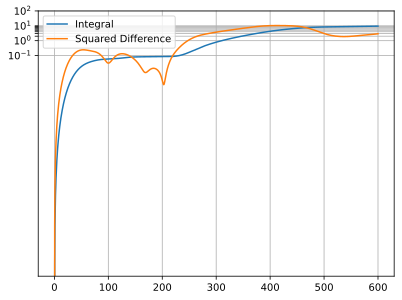

In [37]:
compute_contrast(results = results, 
                 res_idx1= 0, 
                 res_idx2 = 1,
                coeff = kappa,
                a = a,w_d = w_d,tlist = results[0].times,
                fourier = True)

# On reference states:

In [27]:
state_0_dressed = qutip.basis(hilbertspace.dimension, product_to_dressed[(1,0)])
state_1_dressed = qutip.basis(hilbertspace.dimension, product_to_dressed[(2,0)])
state_plus_dressed = (state_0_dressed  +  state_1_dressed).unit()
state_minus_dressed = (state_0_dressed - state_1_dressed).unit()
initial_states  = [state_0_dressed,state_1_dressed,state_plus_dressed,state_minus_dressed ]


products_to_keep = []
for ol in range(8):
    products_to_keep.append([0,ol])
for ql in range(1,10):
    for ol in range(8):
        products_to_keep.append([ql,ol])

def truncate_function(qobj):
    return truncate_custom(qobj, products_to_keep, product_to_dressed)


a = hilbertspace.op_in_dressed_eigenbasis(op=osc.annihilation_operator)
a = qutip.Qobj(a[:, :])
a_trunc = truncate_function(a)

(evals,) = hilbertspace["evals"]
diag_dressed_hamiltonian = (
        2 * np.pi * qutip.Qobj(np.diag(evals),
        dims=[hilbertspace.subsystem_dims] * 2)
)
diag_dressed_hamiltonian = qutip.Qobj(diag_dressed_hamiltonian[:, :])
diag_dressed_hamiltonian = truncate_function(diag_dressed_hamiltonian)


w_d = transition_frequency(hilbertspace,product_to_dressed[(0,0)],product_to_dressed[(0,1)] )
w_d_1 = transition_frequency(hilbertspace,product_to_dressed[(0,7)],product_to_dressed[(0,8)] )

amp1 = 0.007
amp2 = 0.004

stop_t = abs(a[product_to_dressed[(0,0)],product_to_dressed[(0,1)]])/amp1
stop_t2 = abs(a[product_to_dressed[(0,2)],product_to_dressed[(0,3)]])/amp2


tot_time =int(stop_t)
tlist = np.linspace(0, tot_time, tot_time*2)



kappa = 0.005
decay_term = np.sqrt(kappa) * a_trunc
stop_t = abs(a[product_to_dressed[(0,0)],product_to_dressed[(0,1)]])/amp1


write_function()

from temp_functions import mesolve_and_pad, square_cos, square_cos_part1, square_cos_part2
H_with_drive = [
    diag_dressed_hamiltonian,
    [a_trunc+a_trunc.dag(), square_cos_part1],
    [a_trunc+a_trunc.dag(), square_cos_part2]
]

tomo_results = [None] * 4
with ProcessPoolExecutor(max_workers=4) as executor:
    futures = {executor.submit(mesolve_and_pad, 
                               rho0=truncate_function(initial_states[i]), 
                               H_with_drive=H_with_drive,
                               tlist=tlist, 
                               full_dim=hilbertspace.dimension,
                            #    c_ops = [decay_term],  
                               ): i for i in range(4)}
    
    for future in concurrent.futures.as_completed(futures):
        original_index = futures[future]
        tomo_results[original_index] = future.result()


os.remove('temp_functions.py')

10.3%. Run time:   0.67s. Est. time left: 00:00:00:05
10.3%. Run time:   0.69s. Est. time left: 00:00:00:06
10.3%. Run time:   0.69s. Est. time left: 00:00:00:06
10.3%. Run time:   0.70s. Est. time left: 00:00:00:06
20.1%. Run time:   1.44s. Est. time left: 00:00:00:05
20.1%. Run time:   1.48s. Est. time left: 00:00:00:05
20.1%. Run time:   1.48s. Est. time left: 00:00:00:05
20.1%. Run time:   1.49s. Est. time left: 00:00:00:05
30.4%. Run time:   2.13s. Est. time left: 00:00:00:04
30.4%. Run time:   2.17s. Est. time left: 00:00:00:04
30.4%. Run time:   2.18s. Est. time left: 00:00:00:04
30.4%. Run time:   2.18s. Est. time left: 00:00:00:04
40.2%. Run time:   2.79s. Est. time left: 00:00:00:04
40.2%. Run time:   2.82s. Est. time left: 00:00:00:04
40.2%. Run time:   2.84s. Est. time left: 00:00:00:04
40.2%. Run time:   2.84s. Est. time left: 00:00:00:04
50.0%. Run time:   3.45s. Est. time left: 00:00:00:03
50.0%. Run time:   3.47s. Est. time left: 00:00:00:03
50.0%. Run time:   3.49s. Es

In [28]:
if tomo_results[0].states[0].type == 'ket':
    dm_tomo_results_list = []
    for result in tomo_results:
        new_result = qutip.solver.Result()
        new_result.states = [ket2dm(state) for state in result.states]
        new_result.times = result.times
        dm_tomo_results_list.append(new_result)
else:
    dm_tomo_results_list = tomo_results

In [29]:
len(dm_tomo_results_list[0].times)

204

In [30]:
for result in dm_tomo_results_list:
    result.states = result.states[::2]
    result.times = result.times[::2]


In [31]:
import shutil
dir_name = 'temp_tomo'
if os.path.exists(dir_name):
    shutil.rmtree(dir_name)
os.mkdir(dir_name)
tasks = [(dm_tomo_results_list, 
          f'{dir_name}/res_{i}_state_{j}.pkl',
          i, j,  product_to_dressed, qubit_level, osc_level, 1, 2) 
         for i in range(len(dm_tomo_results_list)) 
         for j in range(len(dm_tomo_results_list[i].states))]

from multiprocessing import Pool

with Pool(processes=6) as pool:
    pool.map(compute_and_store_2_level_dm, tasks)

In [32]:
zero = qutip.basis(2, 0)
one = qutip.basis(2, 1)

states_ideal  = [zero,
              one,
              (zero +  one).unit(),
              (zero - one).unit() ]


num_initial_states = len(dm_tomo_results_list)
num_time_steps = len(dm_tomo_results_list[0].times)
two_level_states = []
for i in range(num_initial_states) :
    two_level_states.append([])
    for j in range(num_time_steps):
        with open(f'{dir_name}/res_{i}_state_{j}.pkl', 'rb') as f:
            state = pickle.load(f)
        two_level_states[-1].append(state)


Text(0.5, 0, 'ns')

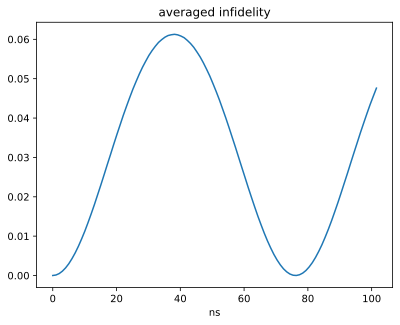

In [33]:
def calc_average_fidelity_with_phase(phase,dms,states_ideal):
    gate = qutip.qip.operations.phasegate(phase)
    fid=[]
    for dm,dm_ideal in zip(dms,states_ideal):
        # new_dm = gate*dm*gate.dag()
        fid.append(qutip.fidelity(dm, gate*dm_ideal))

    return 1-sum(fid)/len(fid)
    


from scipy.optimize import minimize

infidelity = []
phase = []
for idx in range(num_time_steps):
    dms = [states[idx] for states in two_level_states]
    def objective_function(phase):
        return calc_average_fidelity_with_phase(phase[0], dms, states_ideal)
    initial_phase = [0.0]
    bounds = [(0, 2 * 3.141592653589793)]
    opt_result = minimize(objective_function, initial_phase,method="COBYLA")
    infidelity.append(opt_result.fun)
    phase.append(opt_result.x)


plt.plot(dm_tomo_results_list[0].times,infidelity)
plt.title("averaged infidelity")
plt.xlabel("ns")

In [34]:
# plt.plot(dm_tomo_results_list[0].times,phase,label = f'phase')

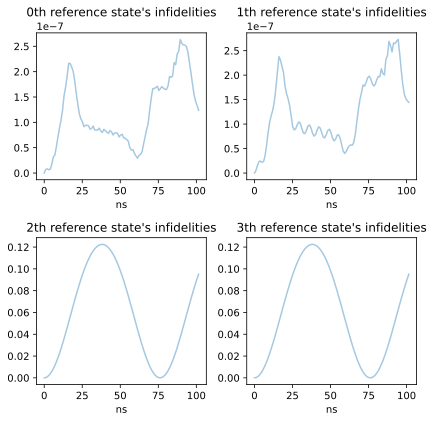

In [35]:
def calc_fidelity_with_phase(phase,dm,state_ideal):
    gate = qutip.qip.operations.phasegate(phase)
    return 1-qutip.fidelity(dm, gate*state_ideal)

    

phases = []
infidelities = []
for i, states in enumerate(two_level_states):
    phases.append([])
    infidelities.append([])
    for idx in range(num_time_steps):
        dm = states[idx]
        def objective_function(params):
            return calc_fidelity_with_phase(params[0], dm, states_ideal[i])
        initial_phase = [0.0]
        opt_result = minimize(objective_function, initial_phase,method="COBYLA")
        phases[-1].append(opt_result.x)
        infidelities[-1].append(opt_result.fun)
# for i in range(4):
#     plt.plot(dm_tomo_results_list[0].times,infidelities[i],label = f'{i}th infidelities',alpha = 0.4)
# plt.title("infidelities")
# plt.xlabel("ns")
# plt.legend()

fig, axs = plt.subplots(2, 2, figsize=(6, 6))
axs = axs.flatten()
for i in range(4):
    axs[i].plot(dm_tomo_results_list[0].times, infidelities[i], label=f'{i}th infidelities', alpha=0.4)
    axs[i].set_title(f"{i}th reference state's infidelities")
    axs[i].set_xlabel("ns")
    # axs[i].legend()

plt.tight_layout()
plt.show()

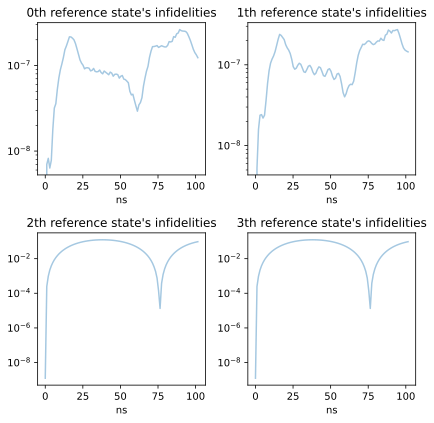

In [41]:

fig, axs = plt.subplots(2, 2, figsize=(6, 6))
axs = axs.flatten()
for i in range(4):
    axs[i].plot(dm_tomo_results_list[0].times, infidelities[i], label=f'{i}th infidelities', alpha=0.4)
    axs[i].set_title(f"{i}th reference state's infidelities")
    axs[i].set_xlabel("ns")
    # axs[i].legend()
    axs[i].set_yscale('log')
    # axs[i].set_ylim(0, 0.001)
    

plt.tight_layout()
plt.show()

In [36]:
two_level_states[3][0]

Quantum object: dims = [[2], [2]], shape = (2, 2), type = oper, isherm = True
Qobj data =
[[ 0.5 -0.5]
 [-0.5  0.5]]

In [37]:
two_level_states[3][-1]

Quantum object: dims = [[2], [2]], shape = (2, 2), type = oper, isherm = True
Qobj data =
[[ 0.49999992+0.j         -0.31819022+0.01752675j]
 [-0.31819022-0.01752675j  0.49999979+0.j        ]]

# If only the first ( 00-01) transition is harmless, then fluroresense on it?